## Project Background and Objective

The electronics e-commerce sector operates in a highly competitive environment where customer acquisition costs are rising and user switching behavior is common. In such conditions, sustainable growth depends not only on attracting traffic but on improving conversion efficiency, customer retention, and revenue concentration among high-value customers.

This project analyzes event-level interaction data (view, cart, purchase) to evaluate:
- Funnel conversion efficiency
- Temporal sales dynamics
- Category and brand performance
- Customer retention sustainability
- Revenue concentration across segments with RFM

The objective is to identify actionable opportunities to improve repeat purchase rate, optimize marketing targeting, and enhance long-term customer value.

## Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats

## Data Cleaning

In [ ]:
df = pd.read_csv('datasets/electronic_ecommerce.csv', encoding='ISO-8859-1')
df['event_time'] = pd.to_datetime(df['event_time'])
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


Data Structure Overview
The dataset contains event-level interactions including:
- user_id
- user_session
- event_type (view, cart, purchase)
- product_id
- category_code
- brand
- event_time

Each row represents a single interaction event, not a transaction.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     885129 non-null  datetime64[us, UTC]
 1   event_type     885129 non-null  str                
 2   product_id     885129 non-null  int64              
 3   category_id    885129 non-null  int64              
 4   category_code  648910 non-null  str                
 5   brand          672765 non-null  str                
 6   price          885129 non-null  float64            
 7   user_id        885129 non-null  int64              
 8   user_session   884964 non-null  str                
dtypes: datetime64[us, UTC](1), float64(1), int64(3), str(4)
memory usage: 60.8 MB


In [4]:
# Missing values summary
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_values.sort_values('Missing Values', ascending=False)

,Missing Values,Percentage (%)
category_code,236219,26.69
brand,212364,23.99
user_session,165,0.02
event_time,0,0.00
event_type,0,0.00
category_id,0,0.00
product_id,0,0.00
price,0,0.00
user_id,0,0.00


The dataset contains approximately 885.129 records and 9 columns. Most columns are complete, except category_code (~26% missing), brand (~24% missing), user_session (minor missing)

In [5]:
# Drop null values in category_code and brand
df = df.dropna(subset=['category_code', 'brand', 'user_session'])
# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
# Missing values summary
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_values.sort_values('Missing Values', ascending=False)

,Missing Values,Percentage (%)
event_time,0,0.0
event_type,0,0.0
product_id,0,0.0
category_id,0,0.0
category_code,0,0.0
brand,0,0.0
price,0,0.0
user_id,0,0.0
user_session,0,0.0


Since category_code and brand contain substantial missing values, and these fields are important for category-level and segmentation analysis, rows with missing values in these columns are removed. Although this reduces dataset size, it ensures analytical consistency and prevents bias from incomplete categorical information

In [6]:
# Convert event_time to datetime
df['event_time'] = pd.to_datetime(df['event_time'])
# Get main category from category_code
df['main_category'] = df['category_code'].str.split('.').str[0]
unique_categories = df['main_category'].unique()
count_categories = df['main_category'].nunique()
print(f"There is {count_categories} Main Categories.")

There is 14 Main Categories.


The category_code column contains hierarchical information (ex: electronics.smartphone). To simplify analysis and improve interpretability, only the main category (first level) is extracted. We got 14 Main Categories for this Data

In [7]:
# drop unnecessary variables
df = df.drop(columns=['category_code', 'category_id', 'user_session'])
df.head(10)

,event_time,event_type,product_id,brand,price,user_id,main_category
0,2020-09-24 11:57:26+00:00,view,139905,zalman,17.16,1515915625519380411,computers
1,2020-09-24 11:57:33+00:00,view,635807,pantum,113.81,1515915625519014356,computers
2,2020-09-24 11:57:59+00:00,view,664325,carver,52.33,1515915625519388062,construction
3,2020-09-24 11:58:24+00:00,view,716611,d-link,53.14,1515915625519388882,computers
4,2020-09-24 11:58:31+00:00,view,716611,d-link,53.14,1515915625519388929,computers
5,2020-09-24 12:00:00+00:00,view,1080093,ricoh,268.17,1515915625519389483,computers
6,2020-09-24 12:00:01+00:00,view,1455459,sony,635.63,1515915625519385419,electronics
7,2020-09-24 12:00:10+00:00,view,3537266,kenwood,92.00,1515915625519389538,auto
8,2020-09-24 12:00:33+00:00,view,523117,asrock,73.81,1515915625519334445,computers
9,2020-09-24 12:00:37+00:00,view,10914,sony,40.95,1515915625519389726,electronics


## Event Analysis

Before building the conversion funnel, we define funnel definition. The funnel is calculated at the User level.
- Users who viewed products
- Users who added products to cart
- Users who completed purchases

Using unique user sets ensures that each customer is counted only once per event type, preventing duplication bias in funnel calculations.

In [8]:
view_users = set(df[df['event_type'] == 'view']['user_id'])
cart_users = set(df[df['event_type'] == 'cart']['user_id'])
purchase_users = set(df[df['event_type'] == 'purchase']['user_id'])

### Funnel Analysis (Nested Events)

This nested approach ensures that conversion rates reflect a realistic customer journey rather than isolated event counts. Here, 'nested' implies a sequence of events triggered by an individual user (ex: view > cart > purchase).

In [9]:
funnel_data = pd.DataFrame({
    'stage': ['View', 'Cart', 'Purchase'],
    'users': [
        len(view_users),
        len(cart_users & view_users),
        len(purchase_users & cart_users & view_users)
    ]
})
# 3) conversion + drop-off

funnel_data["conversion_to_next_%"] = (funnel_data["users"].shift(-1) / funnel_data["users"]) * 100
funnel_data["drop_off_users"] = funnel_data["users"] - funnel_data["users"].shift(-1)
funnel_data["drop_off_rate_%"] = (funnel_data["drop_off_users"] / funnel_data["users"]) * 100
funnel_data

,stage,users,conversion_to_next_%,drop_off_users,drop_off_rate_%
0,View,224741,10.304306,201583.0,89.695694
1,Cart,23158,53.281803,10819.0,46.718197
2,Purchase,12339,NaN,NaN,NaN


In [10]:
fig = go.Figure(go.Funnel(
    y = funnel_data['stage'],
    x = funnel_data['users'],
    textposition = "inside",
    texttemplate = "%{value:,.0f}<br>%{percentTotal:.1%}",
    marker = dict(
        color = ["#1c1847", "#3a3475", "#6b66a6"]
    )
))

for i in range(len(funnel_data) - 1):
    fig.add_annotation(
        x=0,              # Koordinat X di 0 agar tepat di tengah funnel
        y=i + 0.5,        # Posisi Y di antara tahap i dan i+1
        text=f"🔻 <b>Conversion Rate: {funnel_data['conversion_to_next_%'].iloc[i]:.1f}%</b>",
        showarrow=False,
        font=dict(size=13, color="#3ce73c", family="Arial"),
        bgcolor="rgba(255, 255, 255, 0.7)",
        bordercolor="#3ce73c",
        borderwidth=1,
        borderpad=5,
    )

fig.update_layout(
    width=900,
    height=500,
    margin=dict(l=20, r=10, t=60, b=10),
    plot_bgcolor="rgba(0,0,0,0)",
    title=dict(
        text="User Conversion Funnel with Centered Drop-off", 
        x=0.5, 
        font=dict(size=20, color="#1c1847")
    )
)

fig.show()

Funnel Insights (Nested)
- Only 9% of viewers proceed to add items to cart, indicating a significant drop-off at the consideration stage. But for electronics products, this is expected due to higher price points and longer consideration. Customers often compare specifications and prices before committing.
- However, more than 50% of cart users complete the purchase, suggesting strong intent once users reach the cart stage.
- The largest leakage occurs between View and Cart, not Cart to Purchase. Ini sering terjadi di platform electronic ecomerce dimana kebanyakan usernya suka windows shopping dan membandingkan produk yang satu dan produk lainnya sampai menemukan produk yang cocok

### Funnel Analysis (Non-Nested Events)

In [11]:
nonnested_funnel_data = pd.DataFrame({
    'stage': ['View', 'Cart', 'Purchase'],
    'users': [
        len(view_users),
        len(cart_users),
        len(purchase_users)
    ]
})
# 3) conversion + drop-off

nonnested_funnel_data["conversion_to_next_%"] = (nonnested_funnel_data["users"].shift(-1) / nonnested_funnel_data["users"]) * 100
nonnested_funnel_data["drop_off_users"] = nonnested_funnel_data["users"] - nonnested_funnel_data["users"].shift(-1)
nonnested_funnel_data["drop_off_rate_%"] = (nonnested_funnel_data["drop_off_users"] / nonnested_funnel_data["users"]) * 100
nonnested_funnel_data

,stage,users,conversion_to_next_%,drop_off_users,drop_off_rate_%
0,View,224741,10.304306,201583.0,89.695694
1,Cart,23158,56.313153,10117.0,43.686847
2,Purchase,13041,NaN,NaN,NaN


In [12]:
funnel_compare = pd.DataFrame({
    "non_nested_sessions": [nonnested_funnel_data['users'].iloc[0], nonnested_funnel_data['users'].iloc[1], nonnested_funnel_data['users'].iloc[2]],
    "nested_sessions":     [funnel_data['users'].iloc[0], funnel_data['users'].iloc[1], funnel_data['users'].iloc[2]],
}, index=["View", "Cart", "Purchase"])
funnel_compare['diff'] = funnel_compare['non_nested_sessions'] - funnel_compare['nested_sessions']

funnel_compare

,non_nested_sessions,nested_sessions,diff
View,224741,224741,0
Cart,23158,23158,0
Purchase,13041,12339,702


The non-nested approach shows higher purchase counts compared to the nested method. The difference indicates that some users completed purchases without recorded cart events in the dataset.

In [13]:
fig = go.Figure(go.Funnel(
    y = nonnested_funnel_data['stage'],
    x = nonnested_funnel_data['users'],
    textposition = "inside",
    texttemplate = "%{value:,.0f}<br>%{percentTotal:.1%}",
    marker = dict(
        color = ["#1c1847", "#3a3475", "#6b66a6"]
    )
))

for i in range(len(nonnested_funnel_data) - 1):
    fig.add_annotation(
        x=0,              # Koordinat X di 0 agar tepat di tengah funnel
        y=i + 0.5,        # Posisi Y di antara tahap i dan i+1
        text=f"🔻 <b>Conversion Rate: {nonnested_funnel_data['conversion_to_next_%'].iloc[i]:.1f}%</b>",
        showarrow=False,
        font=dict(size=13, color="#3ce73c", family="Arial"),
        bgcolor="rgba(255, 255, 255, 0.7)",
        bordercolor="#3ce73c",
        borderwidth=1,
        borderpad=5,
    )

fig.update_layout(
    width=900,
    height=500,
    margin=dict(l=20, r=10, t=60, b=10),
    plot_bgcolor="rgba(0,0,0,0)",
    title=dict(
        text="User Conversion Funnel (Non-Nested Events)", 
        x=0.5, 
        font=dict(size=20, color="#1c1847")
    )
)

fig.show()

### Monthly Trend by Event

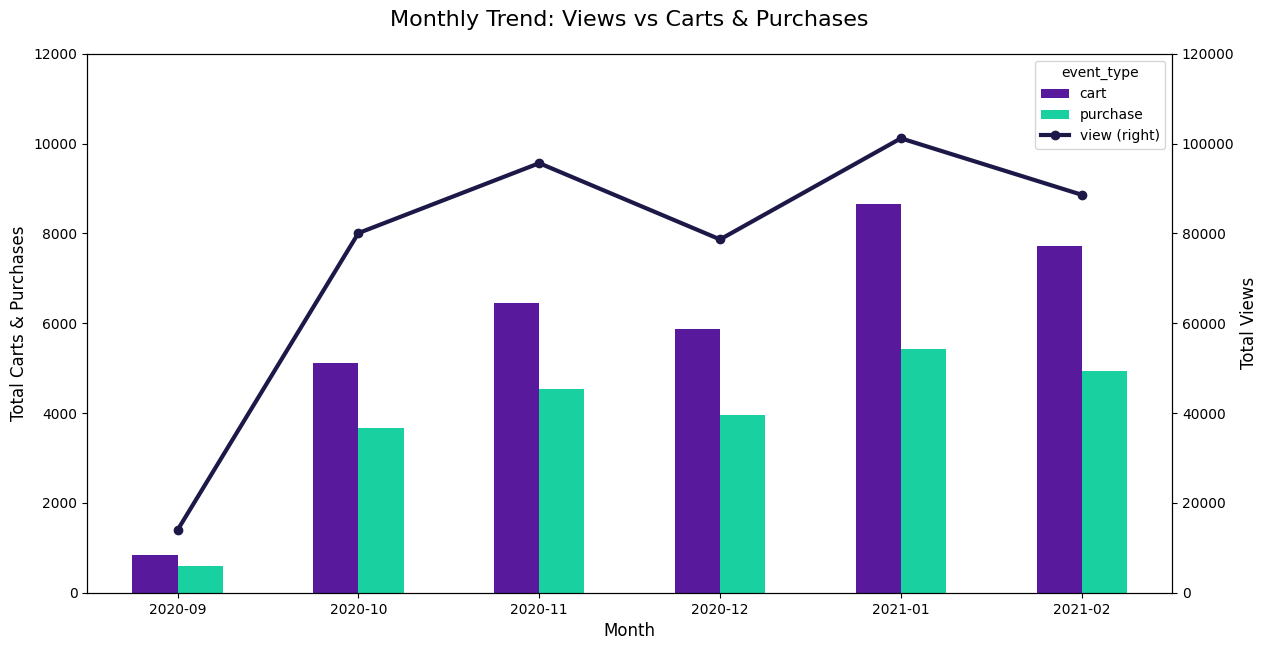

In [14]:
df['event_month'] = df['event_time'].dt.tz_localize(None).dt.to_period('M')
monthly_events = df.groupby(['event_month', 'event_type']).size().unstack(fill_value=0)
monthly_events.index = monthly_events.index.astype(str)

bar_chart = monthly_events[['cart', 'purchase']].plot(
    kind='bar',
    color=["#460091", "#00cc96"],
    figsize=(14, 7),
    rot=0,
    alpha=0.9
)
line_chart = monthly_events['view'].plot(
    kind='line',
    secondary_y=True,
    ax=bar_chart,
    color='#1c1847',
    linewidth=3,
    marker='o',
    legend=True
)
bar_chart.set_title('Monthly Trend: Views vs Carts & Purchases', fontsize=16, pad=20)
bar_chart.set_xlabel('Month', fontsize=12)
bar_chart.set_ylabel('Total Carts & Purchases', fontsize=12)
bar_chart.set_ylim(0, 12000)

line_chart.set_ylabel('Total Views', fontsize=12)
line_chart.set_ylim(0, 120000)
plt.show()

Monthly Trend Insights
- Platform activity increased significantly from September to January, indicating strong growth momentum.
- A noticeable dip occurred in December, followed by recovery in January.
- The increase in purchases closely follows the increase in carts, this is showing stable conversion behavior over time.
- January represents the peak performance period

## Category Analysis

In [15]:
# Uniqe categories and counts
unique_categories = df['main_category'].unique()
category_counts = df['main_category'].value_counts()
print("Unique Main Categories:")

for i,category in enumerate(unique_categories):
    print(f"{i+1}. {category}: {category_counts[category]} items")

Unique Main Categories:
1. computers: 270200 items
2. construction: 18949 items
3. electronics: 124507 items
4. auto: 29973 items
5. appliances: 34774 items
6. stationery: 31215 items
7. kids: 353 items
8. accessories: 1935 items
9. country_yard: 3101 items
10. apparel: 53 items
11. medicine: 320 items
12. furniture: 147 items
13. sport: 217 items
14. jewelry: 111 items


### Revenue and Purchase Distribution by Category

In [16]:
purchases = df[df['event_type'] == 'purchase']
cat_purchase = purchases.groupby('main_category').agg(
    total_revenue=('price', 'sum'),
    total_sold=('product_id', 'count')
)

# make category rvenue sorted and  only select catogory and total revenue
category_revenue = cat_purchase.sort_values(by='total_revenue', ascending=False)[['total_revenue']]
category_revenue['cum_pct'] = category_revenue['total_revenue'].cumsum() / category_revenue['total_revenue'].sum() * 100

# make category sold sorted and  only select catogory and total sold
category_sold = cat_purchase.sort_values(by='total_sold', ascending=False)[['total_sold']]
category_sold['cum_pct'] = category_sold['total_sold'].cumsum() / category_sold['total_sold'].sum() * 100

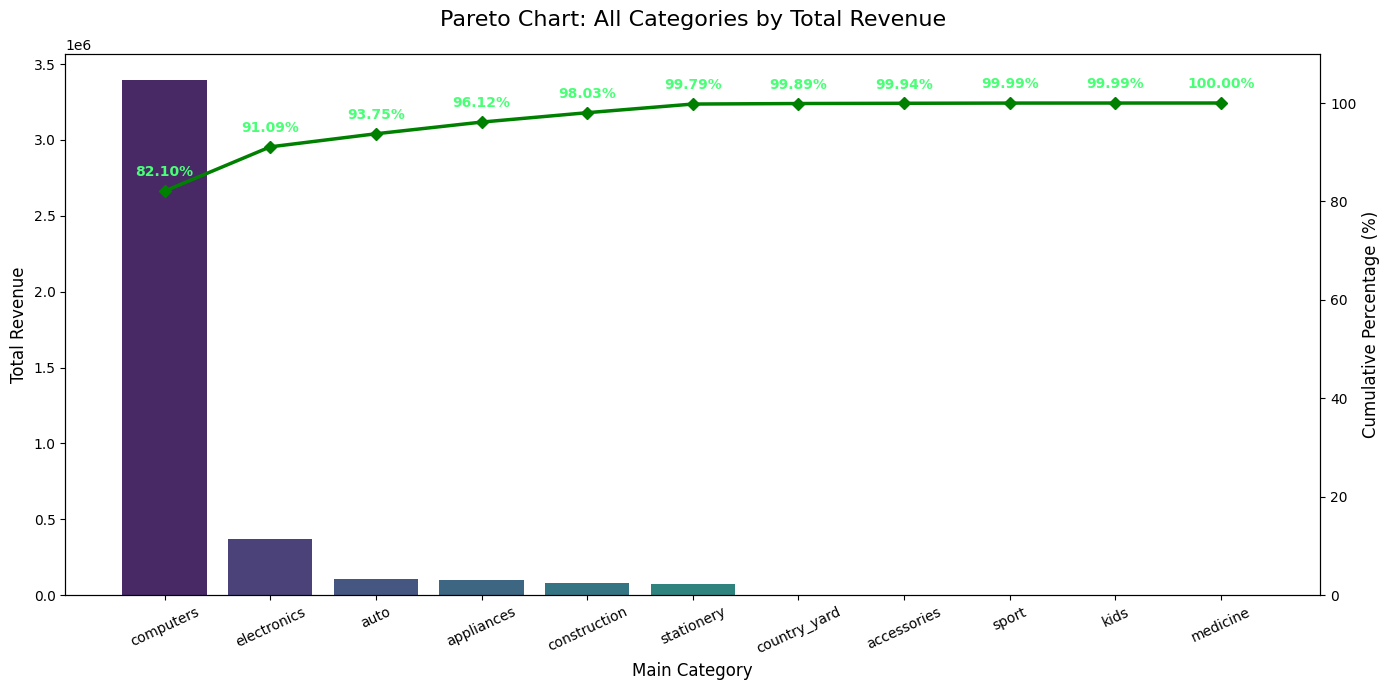

In [17]:
plt.figure(figsize=(14, 7))

# Bar Plot
bar = sns.barplot(
    data=category_revenue, 
    x=category_revenue.index, 
    y='total_revenue', 
    hue=category_revenue.index,
    palette='viridis', 
    legend=False
)
bar.set_title('Pareto Chart: All Categories by Total Revenue', fontsize=16, pad=20)
bar.set_xlabel('Main Category', fontsize=12)
bar.set_ylabel('Total Revenue', fontsize=12)
bar.tick_params(axis='x', rotation=25)

# Add Cumulative Line
cum_line = bar.twinx()
cum_line.plot(category_revenue.index, category_revenue['cum_pct'], color='green', marker='D', linewidth=2.5)
cum_line.set_ylim(0, 110) # Increased slightly to make room for labels
cum_line.set_ylabel('Cumulative Percentage (%)', fontsize=12)
# --- Labeling the Line ---
for i, v in enumerate(category_revenue['cum_pct']):
    cum_line.text(i, v + 3, f'{v:.2f}%', color="#49FF76", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Revenue Contribution by Category (Pareto Analysis)
Key Insights from the Chart:
- The "computers" category dominates revenue, contributing more than 80% of total sales.
- The top 3 categories (computer, electronic and auto) account for over 90% of total revenue.

This indicates that business performance heavily depends on a few product segments, especially computers. But this makes sense, given that electronics carry a much higher price tag compared to other segments.

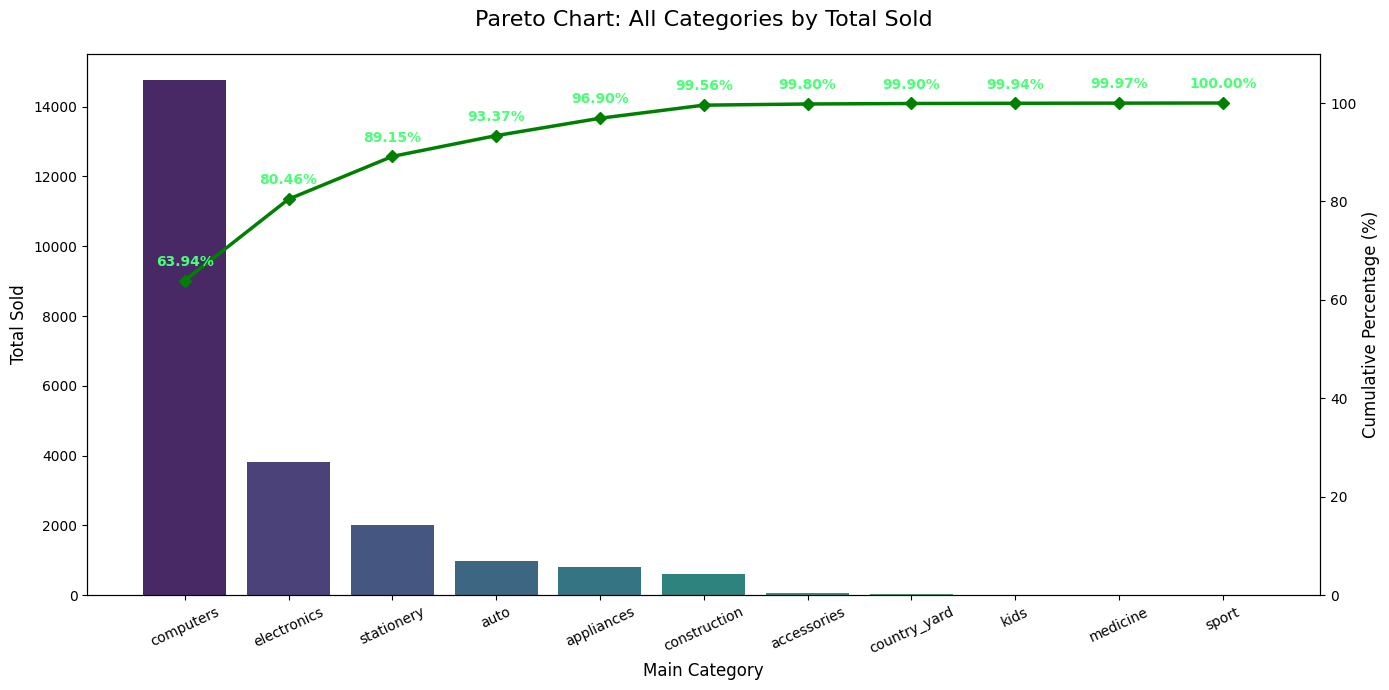

In [18]:
plt.figure(figsize=(14, 7))

# Bar Plot
bar = sns.barplot(
    data=category_sold, 
    x=category_sold.index, 
    y='total_sold', 
    hue=category_sold.index,
    palette='viridis', 
    legend=False
)
bar.set_title('Pareto Chart: All Categories by Total Sold', fontsize=16, pad=20)
bar.set_xlabel('Main Category', fontsize=12)
bar.set_ylabel('Total Sold', fontsize=12)
bar.tick_params(axis='x', rotation=25)

# Add Cumulative Line
cum_line = bar.twinx()
cum_line.plot(category_sold.index, category_sold['cum_pct'], color='green', marker='D', linewidth=2.5)
cum_line.set_ylim(0, 110) # Increased slightly to make room for labels
cum_line.set_ylabel('Cumulative Percentage (%)', fontsize=12)
# --- Labeling the Line ---
for i, v in enumerate(category_sold['cum_pct']):
    cum_line.text(i, v + 3, f'{v:.2f}%', color="#49FF76", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Sold Items Contribution by Category (Pareto Analysis)
- Computers also lead in total units sold, reinforcing their dominance.
- Computers, Electronics, and Stationery collectively account for approximately 90% of total items sold, indicating a highly concentrated demand structure.
- However, some lower-priced categories contribute significant sales volume but limited revenue.
For example, Stationery ranks among the top three most sold categories, yet in the previous revenue analysis it contributes only around 1.76% of total revenue.

### Top Categories by Conversion Rate

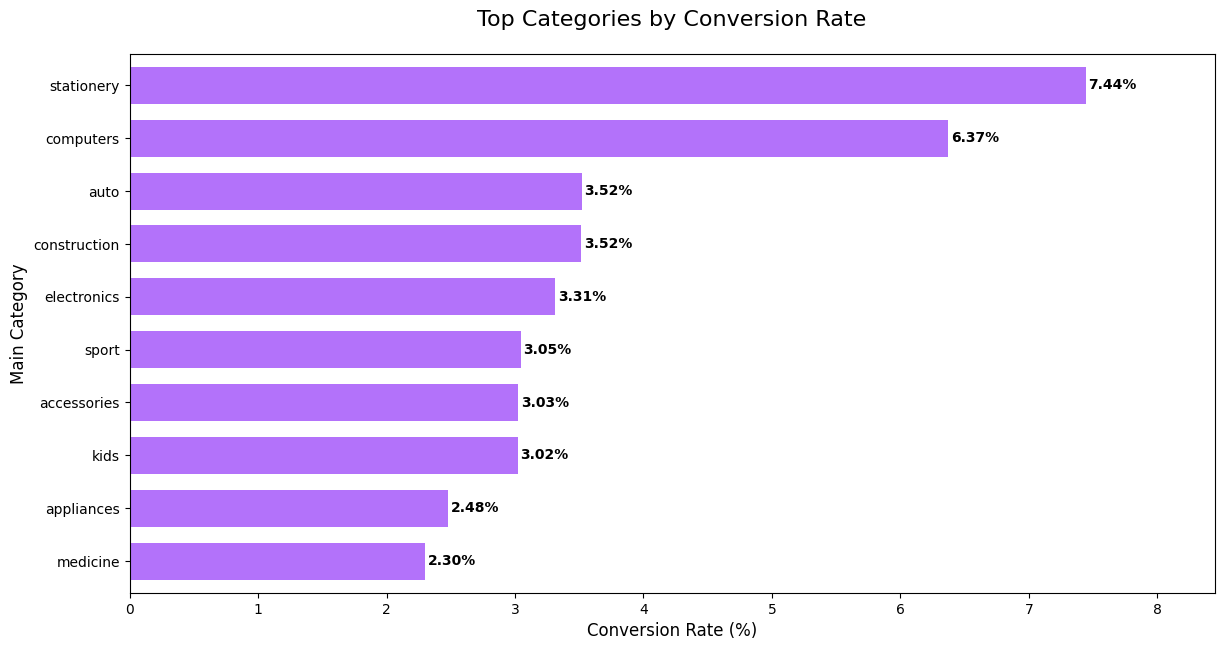

In [19]:
category_events = df.groupby(['main_category', 'event_type']).size().unstack(fill_value=0)
category_events['conversion_rate'] = (category_events['purchase'] / category_events['view']) * 100

category_events.sort_values('conversion_rate', ascending=False, inplace=True)
top_10_category_conv = category_events.head(10).sort_values('conversion_rate', ascending=True)

plt.figure(figsize=(14, 7))
ax = top_10_category_conv['conversion_rate'].plot(kind='barh', color='#ab63fa', alpha=0.9, width=0.7)
ax.set_title('Top Categories by Conversion Rate', fontsize=16, pad=20)
ax.set_xlabel('Conversion Rate (%)', fontsize=12)
ax.set_ylabel('Main Category', fontsize=12)
ax.set_xlim(0, top_10_category_conv['conversion_rate'].max() + 1)  # Add some space for labels
# Tambahkan angka persentase tepat di ujung tiap balok
for i, v in enumerate(top_10_category_conv['conversion_rate']):
    ax.text(v + 0.02, i, f"{v:.2f}%", va='center', fontsize=10, fontweight='bold')

plt.show()


Conversion Insights
- Computers convert well (6.3%) while dominating revenue and units sold.
- Stationery (7.4%) wins on conversion because it’s a low-cost, "buy now" purchase that doesn't require much trust.
- Appliances and Medicine are struggling with low conversion likely because of a brand-category mismatch. Customers may not see us as their "go-to" for these items, leading to more browsing than actual buying.

Focus on Computers as core strength since customers already trust us there. Use Stationery as a simple "add-on" at checkout to boost order volume without extra effort. For Appliances and Medicine, either cut them back or run specific promos, as they currently don't fit the "electronics specialist" brand and are dragging down conversion

### Price Distribution of Each Category (Purchased Items Only)

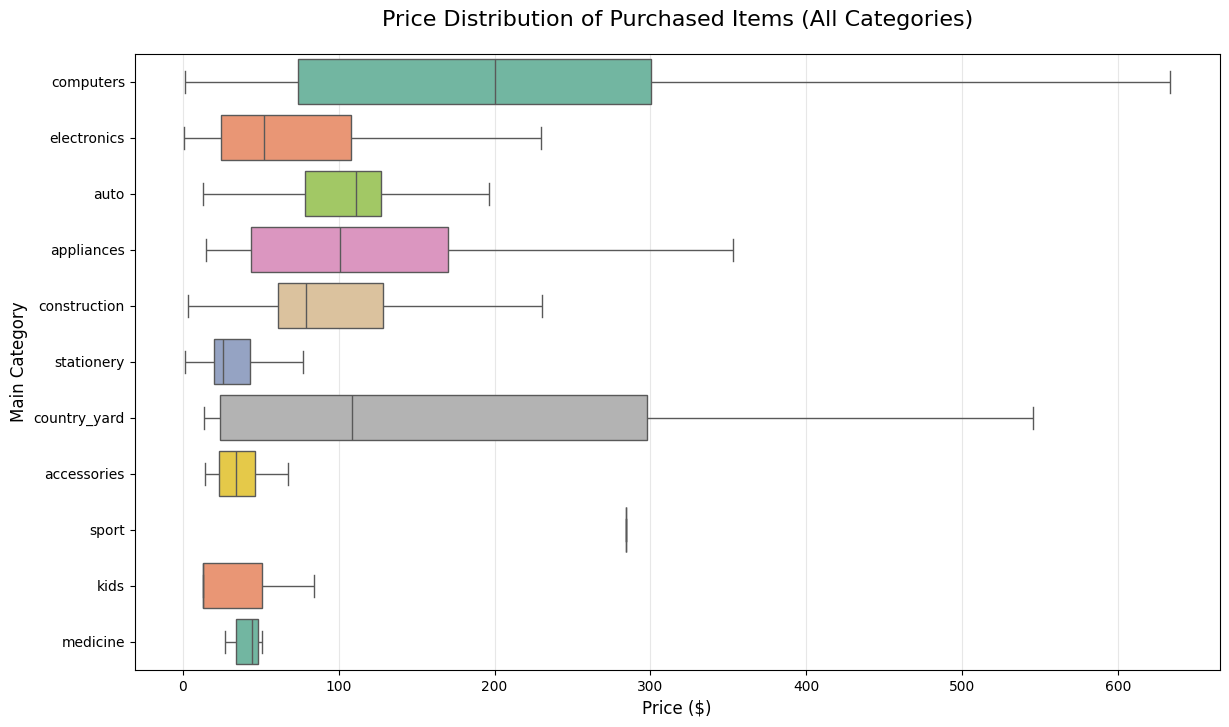

In [20]:
# 1. Ambil list semua kategori yang sudah diurutkan berdasarkan revenue
all_cats_list = category_revenue.index.tolist()

# 2. Plotting Boxplot (Tinggi 8)
plt.figure(figsize=(14, 8))

# UPDATE HUE & LEGEND DI SINI
sns.boxplot(
    data=purchases, 
    x='price', 
    y='main_category', 
    hue='main_category',  # Tambahan baru
    order=all_cats_list, 
    palette='Set2', 
    showfliers=False,
    legend=False          # Tambahan baru
)

plt.title('Price Distribution of Purchased Items (All Categories)', fontsize=16, pad=20)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Main Category', fontsize=12)
plt.grid(axis='x', alpha=0.3)

plt.show()

In [21]:
price_stats = purchases.groupby('main_category')['price'].describe()
price_stats[["mean", "min", "25%", "50%", "75%", "max"]].sort_values('50%', ascending=False)

,mean,min,25%,50%,75%,max
main_category,,,,,,
sport,284.400000,284.40,284.400,284.40,284.400,284.40
computers,229.980697,1.57,73.810,200.35,300.170,3717.65
auto,112.603658,13.17,78.760,110.95,127.480,523.65
country_yard,188.672609,13.48,24.255,108.73,297.940,545.13
appliances,120.464245,14.86,44.130,101.10,170.390,622.84
construction,128.478163,3.37,61.130,78.84,128.790,752.22
electronics,97.437737,0.90,24.510,52.49,107.790,3094.60
medicine,41.155714,27.32,34.220,44.65,48.435,50.81
accessories,37.557273,14.46,23.290,34.56,46.340,94.40


Pricing Insights
- Computers show the highest price range and variability, explaining their dominant revenue share.
- Stationery and accessories are low-priced but show relatively strong conversion.
- High-priced categories drive revenue per transaction, while low-priced categories may drive transaction frequency.

## Brand Analysis

In [22]:
brand_counts = purchases['brand'].value_counts()

print("Unique Brands (Sorted by Count):")
for i, (brand, count) in enumerate(brand_counts.items()):
    print(f"{i+1}. {brand}: {count} items")

Unique Brands (Sorted by Count):
1. msi: 1788 items
2. gigabyte: 1741 items
3. asus: 1259 items
4. palit: 1077 items
5. canon: 1033 items
6. amd: 1020 items
7. sapphire: 917 items
8. sirius: 731 items
9. hp: 690 items
10. samsung: 553 items
11. asrock: 523 items
12. pioneer: 475 items
13. epson: 462 items
14. nv-print: 416 items
15. topon: 395 items
16. cactus: 379 items
17. logitech: 303 items
18. pantum: 295 items
19. powercolor: 272 items
20. mobilepc: 260 items
21. edifier: 251 items
22. pitatel: 220 items
23. intel: 200 items
24. brother: 192 items
25. digma: 184 items
26. pocketbook: 174 items
27. bosch: 174 items
28. bbk: 155 items
29. panasonic: 154 items
30. kenwood: 148 items
31. xerox: 148 items
32. bort: 140 items
33. zalman: 133 items
34. starwind: 126 items
35. steelseries: 125 items
36. janome: 118 items
37. xiaomi: 117 items
38. jvc: 116 items
39. smartbuy: 111 items
40. palmexx: 106 items
41. spigen: 106 items
42. p.i.t.: 106 items
43. dialog: 104 items
44. acv: 104 it

In [23]:
brand_purchase = purchases.groupby('brand').agg(
    total_revenue=('price', 'sum'),
    total_sold=('product_id', 'count')
)

# make brand revenue sorted and  only select brand and total revenue
brand_revenue = brand_purchase.sort_values(by='total_revenue', ascending=False)[['total_revenue']]
brand_revenue['cum_pct'] = brand_revenue['total_revenue'].cumsum() / brand_revenue['total_revenue'].sum() * 100

# make brand sold sorted and  only select brand and total sold
brand_sold = brand_purchase.sort_values(by='total_sold', ascending=False)[['total_sold']]
brand_sold['cum_pct'] = brand_sold['total_sold'].cumsum() / brand_sold['total_sold'].sum() * 100

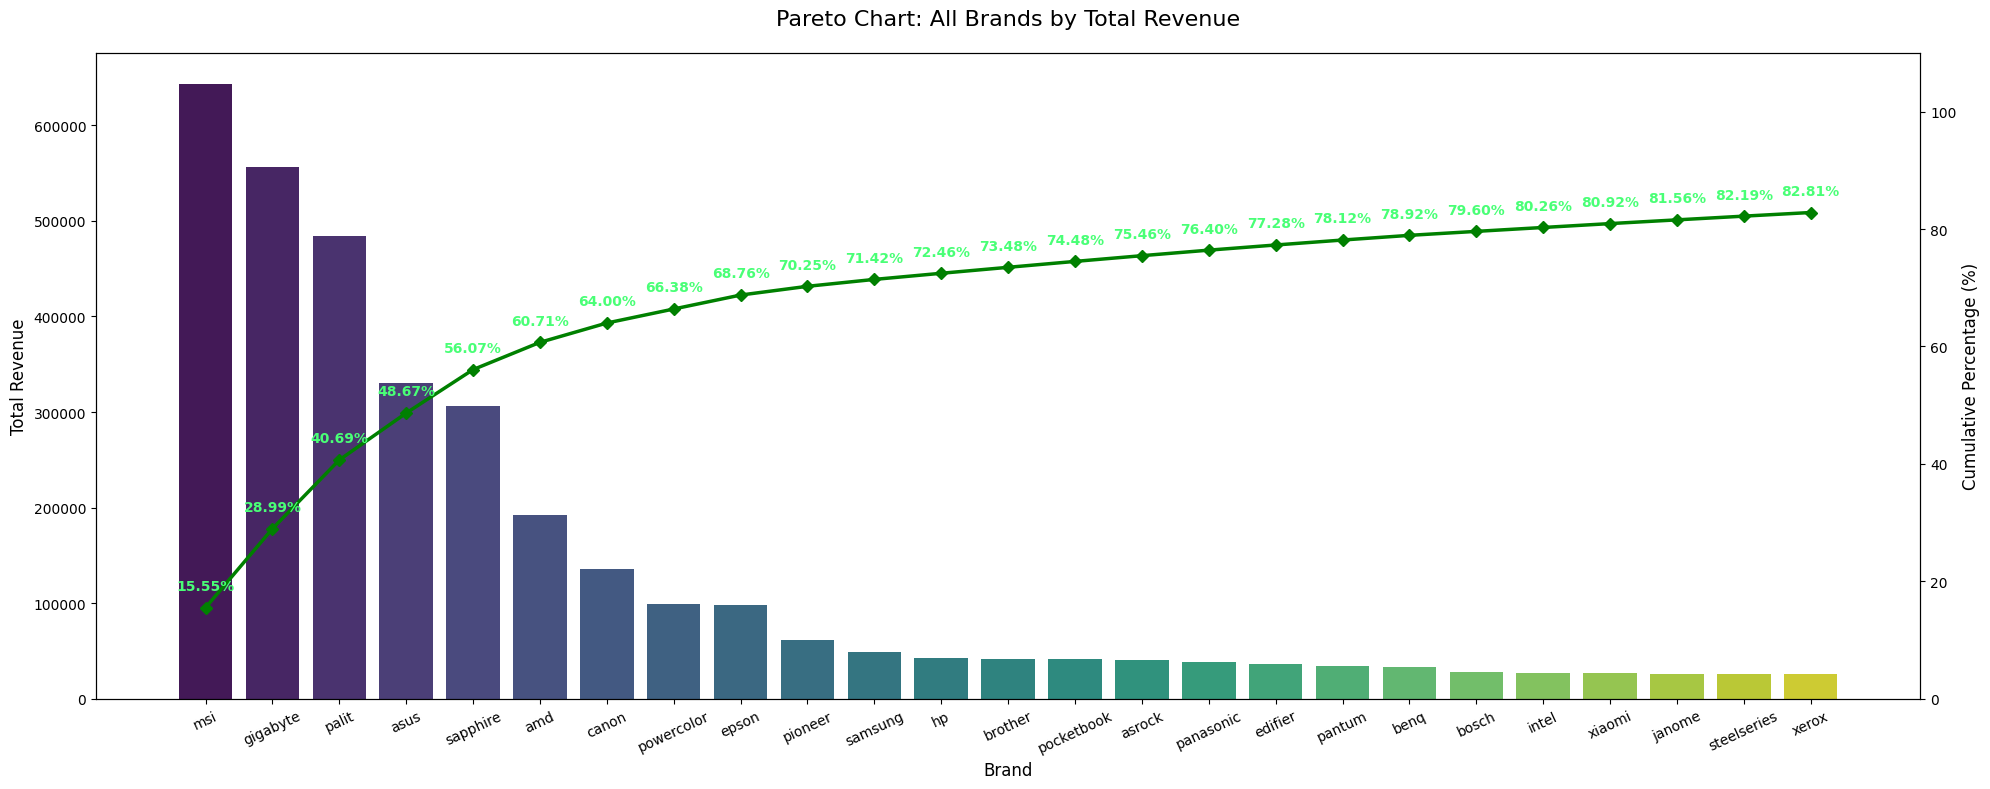

In [24]:
plt.figure(figsize=(20, 8))

# Bar Plot
top_brands_revenue = brand_revenue.head(25)
bar = sns.barplot(
    data=top_brands_revenue, 
    x=top_brands_revenue.index, 
    y='total_revenue', 
    hue=top_brands_revenue.index,
    palette='viridis', 
    legend=False
)
bar.set_title('Pareto Chart: All Brands by Total Revenue', fontsize=16, pad=20)
bar.set_xlabel('Brand', fontsize=12)
bar.set_ylabel('Total Revenue', fontsize=12)
bar.tick_params(axis='x', rotation=25)

# Add Cumulative Line
cum_line = bar.twinx()
cum_line.plot(top_brands_revenue.index, top_brands_revenue['cum_pct'], color='green', marker='D', linewidth=2.5)
cum_line.set_ylim(0, 110) # Increased slightly to make room for labels
cum_line.set_ylabel('Cumulative Percentage (%)', fontsize=12)
# --- Labeling the Line ---
for i, v in enumerate(top_brands_revenue['cum_pct']):
    cum_line.text(i, v + 3, f'{v:.2f}%', color="#49FF76", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Key insight from chart:
- Top 4 brand (MSI, Gigabyte, Palit, asus) dominate over 50% of revenue
- The top performers are heavily skewed toward High-End Components (GPUs), showing that revenue is driven by high price hardware rather than general electronics
- Just 6% of brands (20 out of 334) generate 80% of total revenue

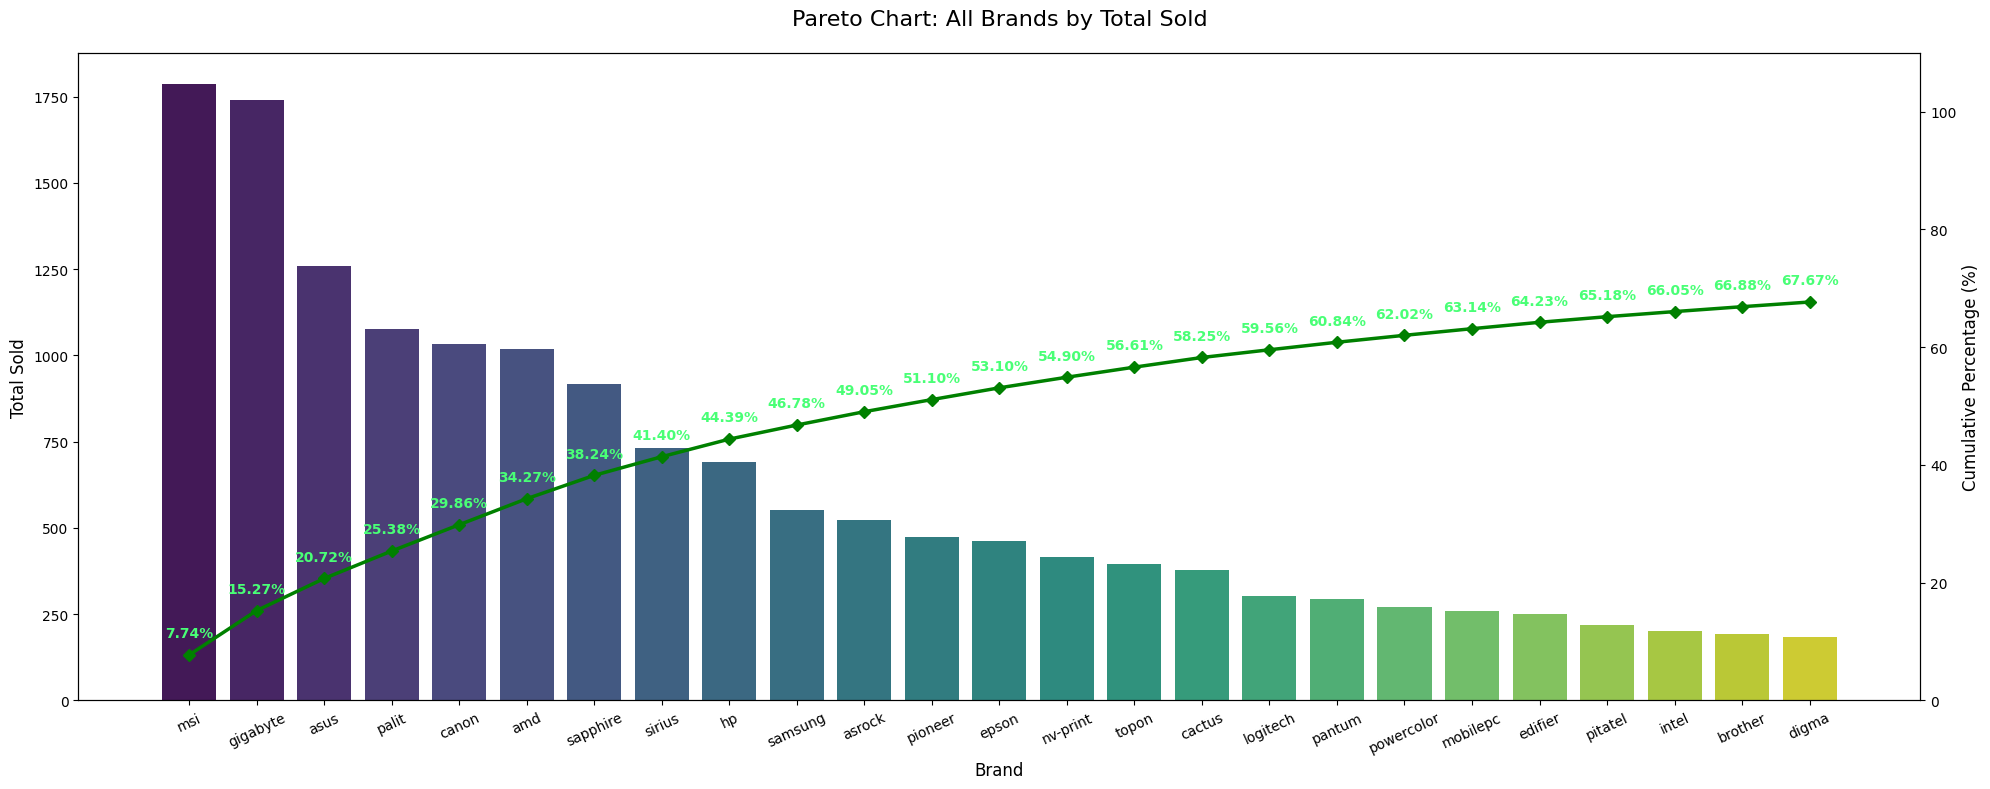

In [25]:
plt.figure(figsize=(20, 8))

# Bar Plot
top_brands_sold = brand_sold.head(25)
bar = sns.barplot(
    data=top_brands_sold, 
    x=top_brands_sold.index, 
    y='total_sold', 
    hue=top_brands_sold.index,
    palette='viridis', 
    legend=False
)
bar.set_title('Pareto Chart: All Brands by Total Sold', fontsize=16, pad=20)
bar.set_xlabel('Brand', fontsize=12)
bar.set_ylabel('Total Sold', fontsize=12)
bar.tick_params(axis='x', rotation=25)

# Add Cumulative Line
cum_line = bar.twinx()
cum_line.plot(top_brands_sold.index, top_brands_sold['cum_pct'], color='green', marker='D', linewidth=2.5)
cum_line.set_ylim(0, 110) # Increased slightly to make room for labels
cum_line.set_ylabel('Cumulative Percentage (%)', fontsize=12)
# --- Labeling the Line ---
for i, v in enumerate(top_brands_sold['cum_pct']):
    cum_line.text(i, v + 3, f'{v:.2f}%', color="#49FF76", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

- Unlike revenue, unit sales are much more distributed; the top 25 brands only account for 67% of total units sold. This suggests that customers are buying a wider variety of brands for lower-priced items, even if they stick to "big names" for expensive components.
- MSI, Gigabyte, Asus, and Palit remain the top 4 performers in volume, proving they dominate both premium (revenue) and mass-market (units) segments.

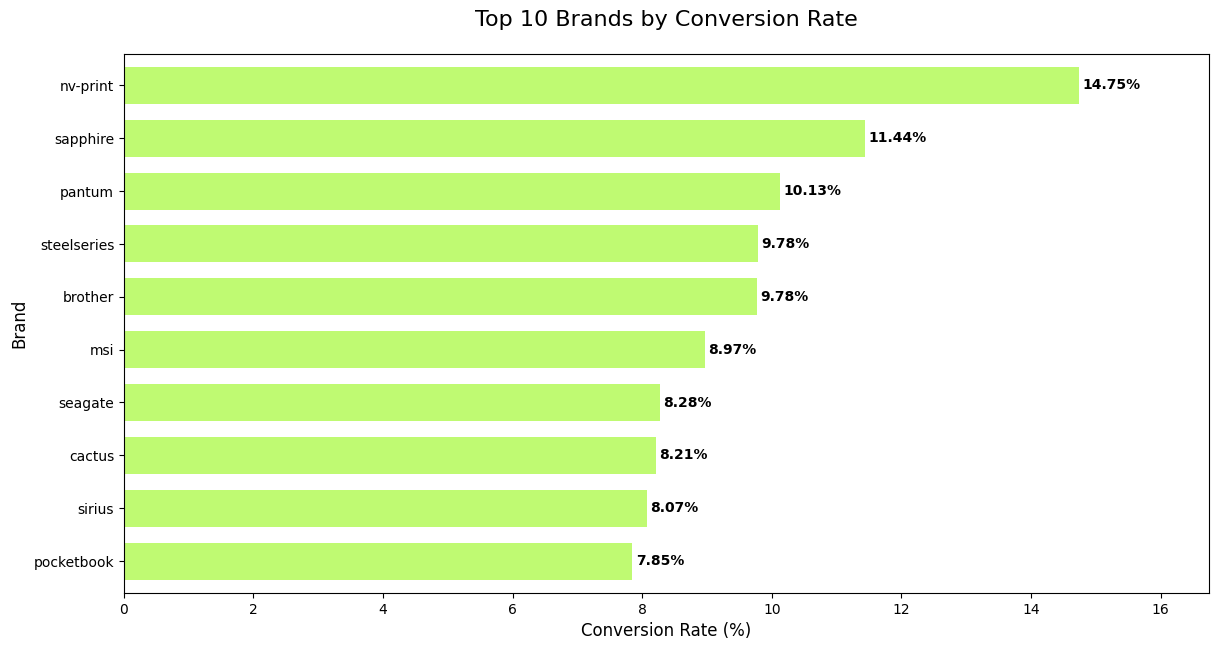

In [26]:
brand_events = df.groupby(['brand', 'event_type']).size().unstack(fill_value=0)
brand_events['conversion_rate'] = (brand_events['purchase'] / brand_events['view']) * 100

# Set Threshold untuk filter brand untuk menghindari anomali dari brand dengan traffic sangat rendah
# Cara 1: Memakai Statistik seperti Percentil atau Mean
# view_treshold = brand_events['view'].quantile(0.8)

# Cara 2: Memakai Threshold Absolut (misal brand bisa dihitung conversion rate nya jika memiliki minimal 1000 views)
view_treshold = 1000

brand_events = brand_events[brand_events['view'] > view_treshold]
brand_events.sort_values('conversion_rate', ascending=False, inplace=True)
top_10_brands_conv = brand_events.head(10).sort_values('conversion_rate', ascending=True)

plt.figure(figsize=(14, 7))
ax = top_10_brands_conv['conversion_rate'].plot(
    kind='barh', 
    color="#b8fa63", 
    alpha=0.9, 
    width=0.7
    )
ax.set_title('Top 10 Brands by Conversion Rate', fontsize=16, pad=20)
ax.set_xlabel('Conversion Rate (%)', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
# Add some space for labels
ax.set_xlim(0, top_10_brands_conv['conversion_rate'].max() + 2)
# Tambahkan angka persentase tepat di ujung tiap balok
for i, v in enumerate(top_10_brands_conv['conversion_rate']):
    ax.text(v + 0.05, i, f"{v:.2f}%", va='center',
            fontsize=10, fontweight='bold')

plt.show()

A minimum threshold of 1,000 views was applied to filter out brand with low-traffic anomalies, ensuring the ranking represents brands with statistically significant performance rather than outliers.
- nv-print dominates the ranking with a 14.75% conversion rate, significantly outperforming the rest of the field and exceeding the runner-up (sapphire) by over 3 percentage points.
- Only the top three brands (nv-print (14.75%), sapphire (11.44%), and pantum (10.13%)) that successfully breached the 10% CVR
- The list is heavily represented by Tech and Hardware brands (MSI, Seagate, Steelseries), indicating a strong "Purchase Intent" and high consumer trust within this specific brand.

## Time Analysis

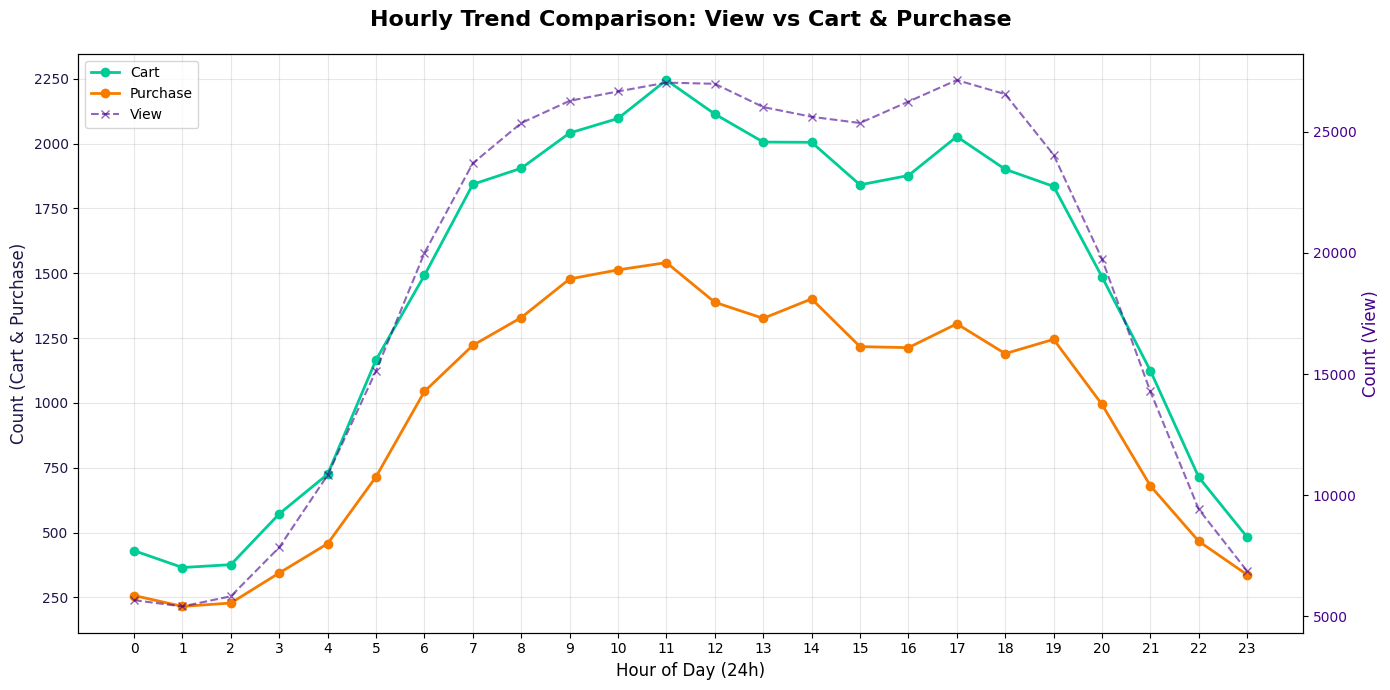

In [27]:
import matplotlib.pyplot as plt

# 1. Siapkan data (Asumsi df sudah memiliki kolom 'hour' dan 'event_type')
df['hour'] = df['event_time'].dt.hour
hourly_stats = df.groupby(['hour', 'event_type']).size().unstack(fill_value=0)

# 2. Plotting dengan Dual Axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Sumbu Y Pertama (Kiri) untuk Cart dan Purchase
ax1.plot(hourly_stats.index, hourly_stats['cart'], color='#00cc96', marker='o', label='Cart', linewidth=2)
ax1.plot(hourly_stats.index, hourly_stats['purchase'], color='#f57c00', marker='o', label='Purchase', linewidth=2)
ax1.set_xlabel('Hour of Day (24h)', fontsize=12)
ax1.set_ylabel('Count (Cart & Purchase)', fontsize=12, color='#1c1847')
ax1.tick_params(axis='y', labelcolor='#1c1847')

# Sumbu Y Kedua (Kanan) untuk View
ax2 = ax1.twinx()
ax2.plot(hourly_stats.index, hourly_stats['view'], color='#460091', linestyle='--', marker='x', label='View', alpha=0.6)
ax2.set_ylabel('Count (View)', fontsize=12, color='#460091')
ax2.tick_params(axis='y', labelcolor='#460091')

# 3. Pengaturan Tampilan
plt.title('Hourly Trend Comparison: View vs Cart & Purchase', fontsize=16, pad=20, fontweight='bold')
plt.xticks(range(0, 24))
ax1.grid(True, alpha=0.3)

# Menggabungkan Legend dari kedua sumbu
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

- Platform activity increases significantly starting at 05:00 and remains high between 08:00 and 17:00. All three metrics peak around 11:00, indicating strong daytime engagement. This suggests that users are highly active during working hours, possibly browsing and purchasing during office breaks or productive hours.
- A noticeable spike occurs between 10:00 and 12:00, where both purchase and cart activity reach their highest levels. This time window may be optimal for targeted promotions or push notifications.
- After 19:00, there is a sharp decline across all metrics, especially purchases. This suggests lower transactional intent in late evening hours.

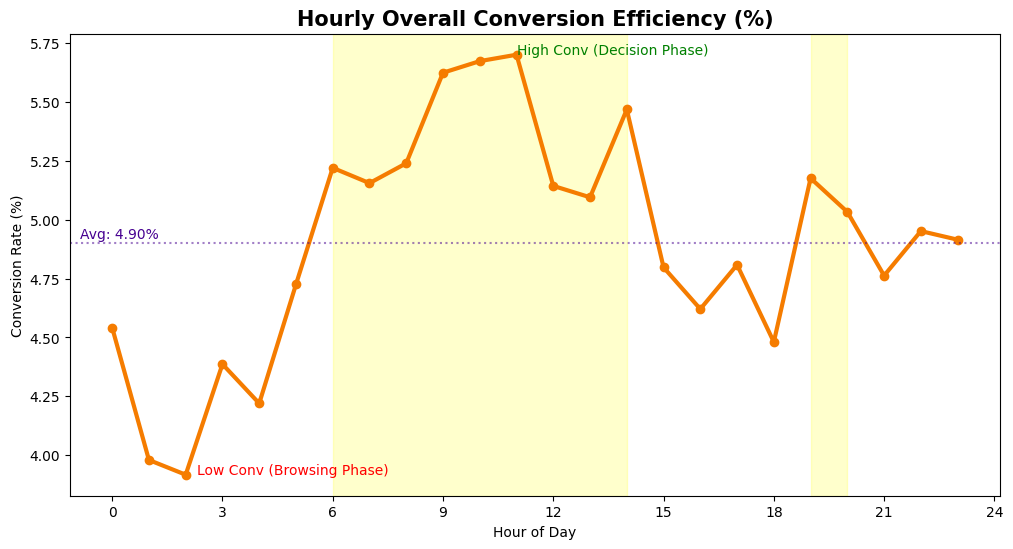

In [28]:
# Hitung Conversion Rate per Jam (Purchase / View)
hourly_stats = df.groupby(['hour', 'event_type']).size().unstack(fill_value=0)
hourly_stats['conversion_rate'] = (hourly_stats['purchase'] / hourly_stats['view']) * 100
avg = hourly_stats['conversion_rate'].mean()

# Line Plot
plt.figure(figsize=(12, 6))
ax = hourly_stats['conversion_rate'].plot(kind='line', marker='o', color='#f57c00', linewidth=3)

# Title and Labels
plt.title('Hourly Overall Conversion Efficiency (%)', fontsize=15, fontweight='bold')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Hour of Day')
plt.xticks(range(0, 25, 3))

# Line and Area
plt.axhline(avg, color='#460091', linestyle=':', alpha=0.5, label='Avg Conv')
plt.axvspan(6, 14, color='yellow', alpha=0.2, label='Working Hours (Peak)')
plt.axvspan(19, 20, color='yellow', alpha=0.2, label='Working Hours (Peak)')

# Add annotations for key insights
min_h = hourly_stats['conversion_rate'].idxmin()
max_h = hourly_stats['conversion_rate'].idxmax()
plt.annotate('Avg: {:.2f}%'.format(avg), xy=(0.2, avg+0.02), fontsize=10, color='#460091', ha='center')
plt.annotate('Low Conv (Browsing Phase)', xy=(min_h+0.3, hourly_stats['conversion_rate'][min_h]), color='red')
plt.annotate('High Conv (Decision Phase)', xy=(max_h, hourly_stats['conversion_rate'][max_h]), color='green')

plt.show()

- The overall average conversion rate is approximately 4.90%
- Conversion rates remain below average during early morning hours, reaching the lowest levels around 02:00–03:00. This suggests Users are more likely just "window shopping" or lower purchasing intent
- Conversion efficiency increases significantly from 06:00 and remains above average until 14.00 with peak conversion occurs around 09:00–11:00, reaching approximately 5.6–5.7%.
- There is a secondary decision window, conversion rate lightly exceeding the daily average during early evening hours (19:00-20:00)

Given that conversion efficiency peaks during morning to midday hours (09:00–11:00) and declines significantly during late-night periods, marketing efforts and promotional campaigns should be concentrated within high-intent time windows to maximize ROI. Budget allocation during low-conversion hours should be optimized or shifted toward awareness rather than direct sales objectives.

## Cohort

### User Retention Analysis

In [29]:
df_retention = df[df['event_type'] == 'purchase'].copy()
df_retention['cohort_month'] = df_retention.groupby('user_id')['event_month'].transform('min')
df_retention['cohort_index'] = (
    df_retention['event_month'].astype(int)
    - df_retention['cohort_month'].astype(int)
    + 1
)
df_retention[['user_id', 'event_month', 'cohort_month', 'cohort_index']].head()

,user_id,event_month,cohort_month,cohort_index
18,1515915625519390468,2020-09,2020-09,1
38,1515915625513574486,2020-09,2020-09,1
66,1515915625519356010,2020-09,2020-09,1
84,1515915625513574486,2020-09,2020-09,1
93,1515915625513574581,2020-09,2020-09,1


In [30]:
user_cohort_data = df_retention.groupby(['cohort_month', 'cohort_index'])['user_id'].nunique().reset_index()
user_cohort_pivot = user_cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='user_id'
)
user_cohort_pivot

cohort_index,1,2,3,4,5
cohort_month,,,,,
2020-09,369.0,19.0,3.0,1.0,1.0
2020-10,2151.0,43.0,9.0,2.0,2.0
2020-11,2526.0,45.0,17.0,3.0,NaN
2020-12,2263.0,44.0,14.0,NaN,NaN
2021-01,3060.0,87.0,NaN,NaN,NaN
2021-02,2672.0,NaN,NaN,NaN,NaN


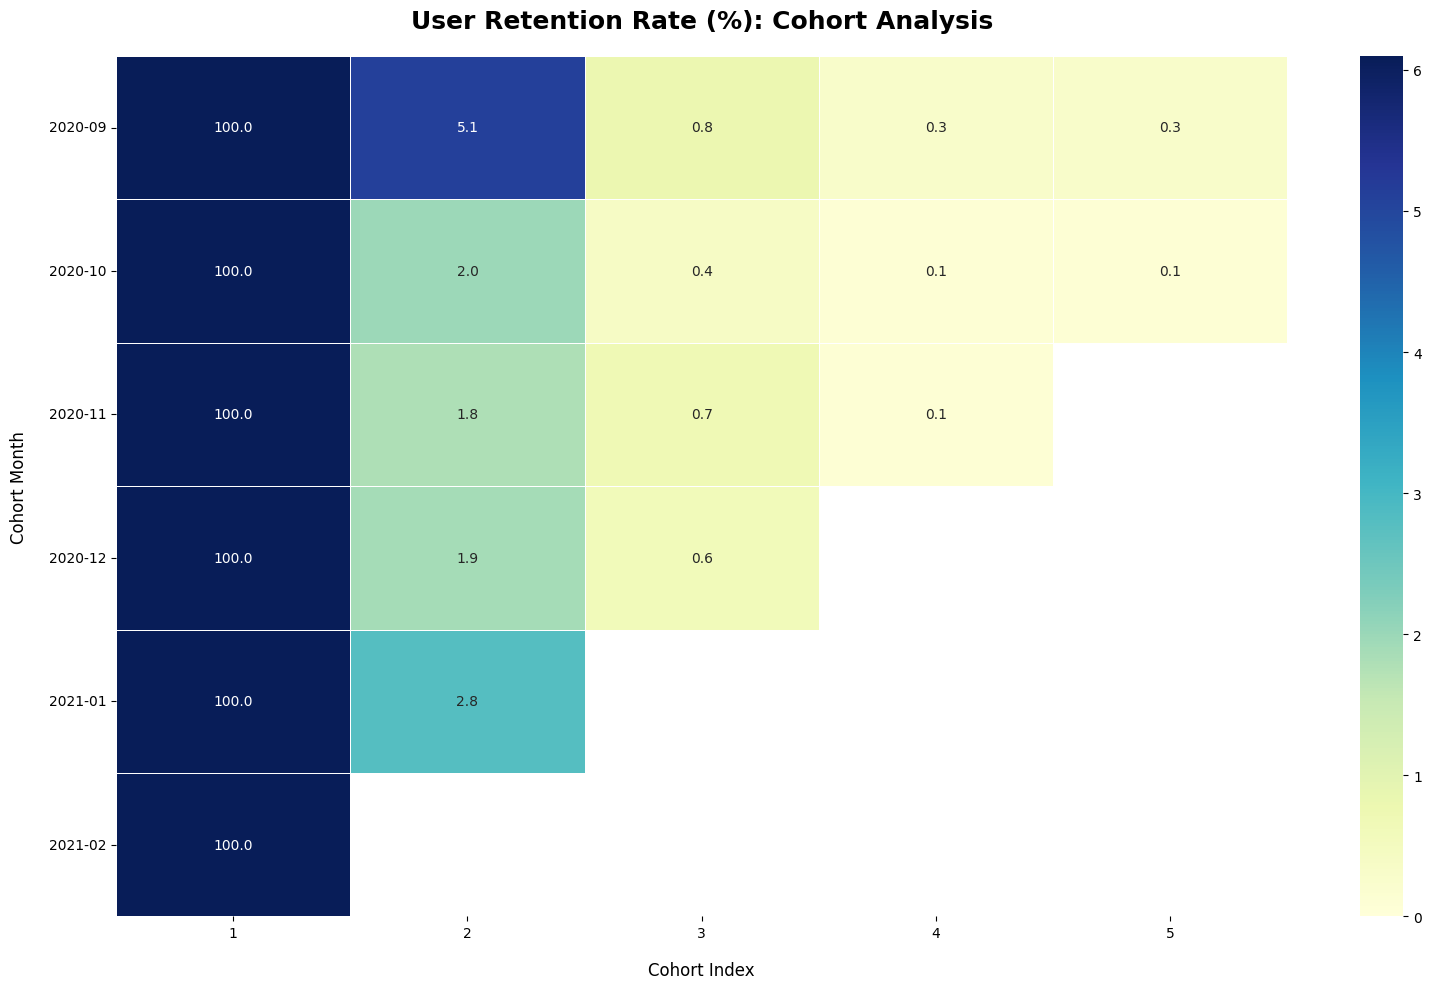

In [31]:
user_cohort_initial = user_cohort_pivot[1]
user_retention = (user_cohort_pivot.divide(user_cohort_initial, axis=0) * 100).round(1)
max_uret = user_retention.iloc[:, 1:].max().max() + 1

plt.figure(figsize=(16, 10))
sns.heatmap(
    user_retention,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    vmin=0.0,
    vmax=max_uret,
    linewidths=0.5,
    linecolor='white'
)

# Judul yang proper untuk portofolio
plt.title('User Retention Rate (%): Cohort Analysis', fontsize=18, pad=20, fontweight='bold')
plt.ylabel('Cohort Month', fontsize=12, labelpad=15)
plt.xlabel('Cohort Index', fontsize=12, labelpad=15)
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

Cohort analysis shows extremely low user retention beyond the first month. While all cohorts start at 100% in Month 0, retention drops sharply in Month 1 (around 2–5%) and declines further to below 1% in subsequent months. The September cohort performs slightly better in early retention, but the overall pattern is consistent across months, indicating weak long-term engagement and limited repeat purchase behavior. This suggests the business is heavily dependent on new user acquisition rather than sustainable customer retention.

### Transaction Retention Analysis

In [32]:
order_cohort_data = df_retention.groupby(['cohort_month', 'cohort_index']).size().reset_index(name='order_count')
order_cohort_pivot = order_cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='order_count'
)
order_cohort_pivot

cohort_index,1,2,3,4,5
cohort_month,,,,,
2020-09,588.0,32.0,4.0,1.0,2.0
2020-10,3627.0,90.0,30.0,3.0,2.0
2020-11,4450.0,65.0,31.0,3.0,NaN
2020-12,3865.0,73.0,19.0,NaN,NaN
2021-01,5306.0,184.0,NaN,NaN,NaN
2021-02,4730.0,NaN,NaN,NaN,NaN


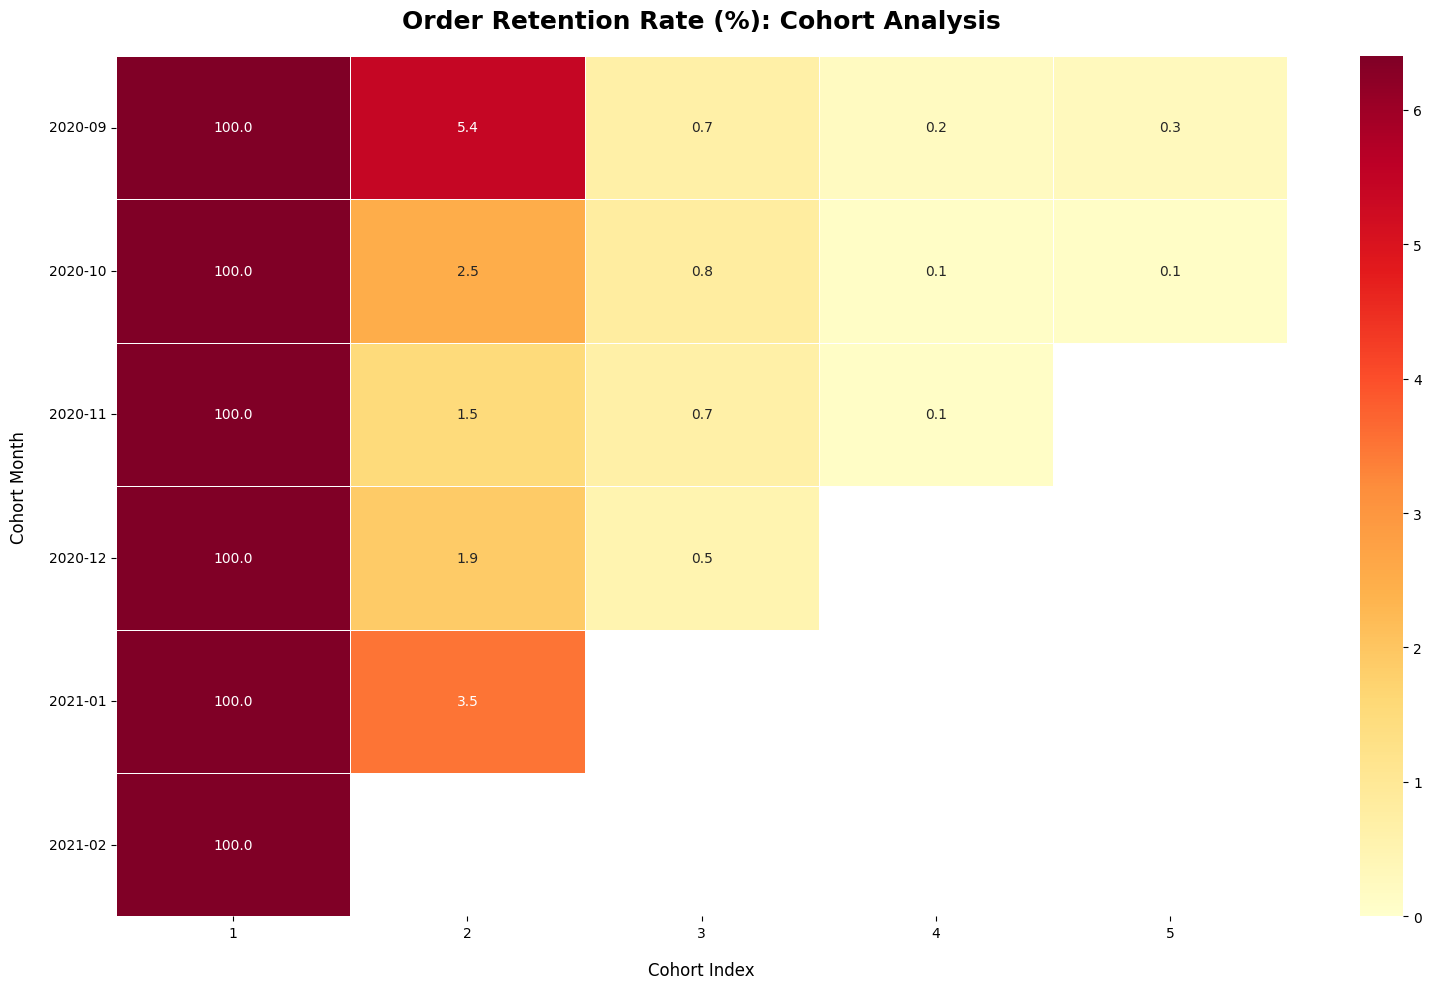

In [33]:
order_cohort_initial = order_cohort_pivot[1]
order_retention = (order_cohort_pivot.divide(order_cohort_initial, axis=0) * 100).round(1)
max_orret = order_retention.iloc[:, 1:].max().max() + 1

plt.figure(figsize=(16, 10))
sns.heatmap(
    order_retention,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    vmin=0.0,
    vmax=max_orret,
    linewidths=0.5,
    linecolor='white'
)

# Judul yang proper untuk portofolio
plt.title('Order Retention Rate (%): Cohort Analysis', fontsize=18, pad=20, fontweight='bold')
plt.ylabel('Cohort Month', fontsize=12, labelpad=15)
plt.xlabel('Cohort Index', fontsize=12, labelpad=15)
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

Order retention mirrors the user retention pattern, with a sharp decline after the first month. Although all cohorts begin at 100% in Month 0, retention drops significantly in Month 1 (approximately 1.5–5.4%) and falls below 1% in subsequent months. The September and January cohorts show relatively stronger early retention, but the overall trend indicates weak repeat purchasing behavior. This suggests that most customers place only one order, highlighting limited order frequency and low customer lifetime value.

### Revenue Retention Analysis

In [34]:
revenue_cohort_data = df_retention.groupby(['cohort_month', 'cohort_index'])['price'].sum().reset_index()
revenue_cohort_pivot = revenue_cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='price'
)
revenue_cohort_pivot

cohort_index,1,2,3,4,5
cohort_month,,,,,
2020-09,76482.55,7084.17,920.39,173.59,46.96
2020-10,424296.15,14860.02,5001.50,582.68,261.10
2020-11,595949.07,9772.93,7032.55,455.80,NaN
2020-12,634045.13,19848.21,2282.78,NaN,NaN
2021-01,1186466.69,47583.76,NaN,NaN,NaN
2021-02,1104931.67,NaN,NaN,NaN,NaN


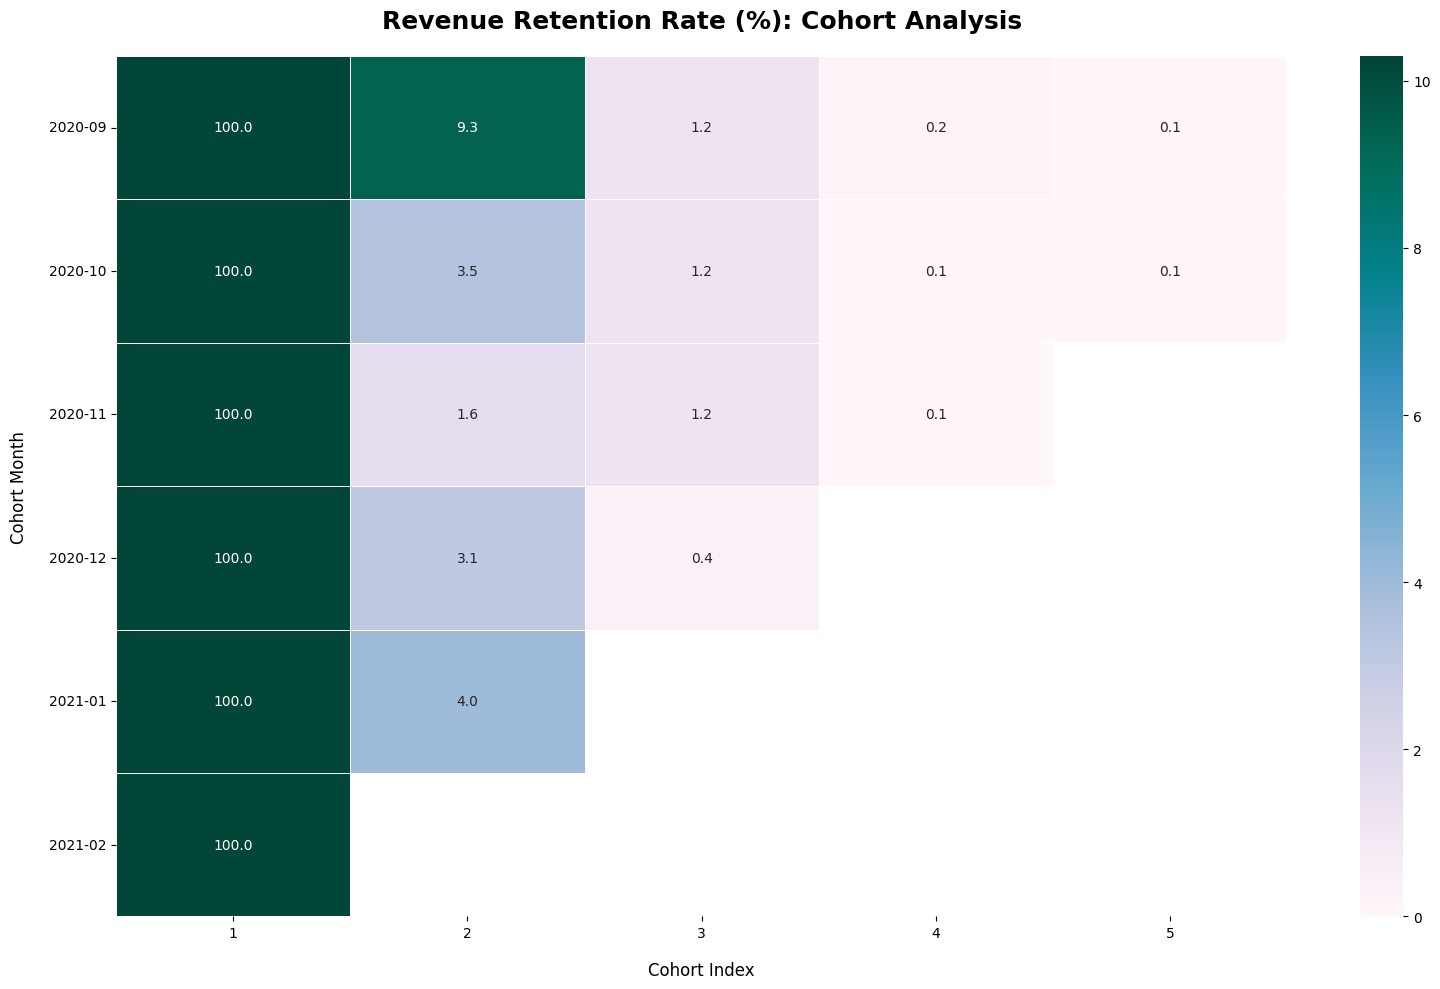

In [36]:
revenue_cohort_initial = revenue_cohort_pivot[1]
revenue_retention = (revenue_cohort_pivot.divide(revenue_cohort_initial, axis=0) * 100).round(1)
max_revret = revenue_retention.iloc[:, 1:].max().max() + 1

plt.figure(figsize=(16, 10))
sns.heatmap(
    revenue_retention,
    annot=True,
    fmt='.1f',
    cmap='PuBuGn',
    vmin=0.0,
    vmax=max_revret,
    linewidths=0.5,
    linecolor='white'
)

# Judul yang proper untuk portofolio
plt.title('Revenue Retention Rate (%): Cohort Analysis', fontsize=18, pad=20, fontweight='bold')
plt.ylabel('Cohort Month', fontsize=12, labelpad=15)
plt.xlabel('Cohort Index', fontsize=12, labelpad=15)
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

Revenue retention declines sharply after the first month, mirroring the weak user retention pattern. However, in several cohorts, revenue retention remains relatively higher than user retention, indicating that although only a small proportion of users return, those who do tend to generate disproportionately higher revenue. This suggests the presence of a high-value returning customer segment.

## RFM

In [38]:
df_rfm = df[df['event_type'] == 'purchase'].copy()
df_rfm = df_rfm.drop(columns= ['event_type', 'product_id', 'brand', 'main_category', 'hour'])

In [39]:
recency_list = {"2020-09": 5, "2020-10": 4, "2020-11": 3, "2020-12": 2, "2021-01": 1, "2021-02": 0}
df_rfm.loc[:, 'Recency'] = df_rfm['event_month'].astype(str).map(recency_list)
df_rfm['Recency'] = df_rfm['Recency'].astype(int)

df_R = df_rfm.groupby('user_id')['Recency'].min().reset_index(name='Recency')
df_F = df_rfm.groupby('user_id').size().reset_index(name='Frequency')
df_M = df_rfm.groupby('user_id')['price'].sum().reset_index(name='Monetary')

df_rfm_final = df_R.merge(df_F, on='user_id').merge(df_M, on='user_id').drop(columns='user_id')
df_rfm_final.head()

conditions=np.abs(stats.zscore(df_rfm_final.loc[:,['Recency','Frequency','Monetary']]) < 3).all(axis=1)
df_rfm_cleaned=df_rfm_final.loc[conditions,:]
df_rfm_cleaned.head(10)

,Recency,Frequency,Monetary
0,4,1,119.03
1,5,1,55.16
2,4,3,57.15
3,3,2,345.72
4,4,2,57.85
5,5,1,236.97
6,4,3,155.04
7,3,1,120.27
8,3,2,210.28
9,3,3,271.59


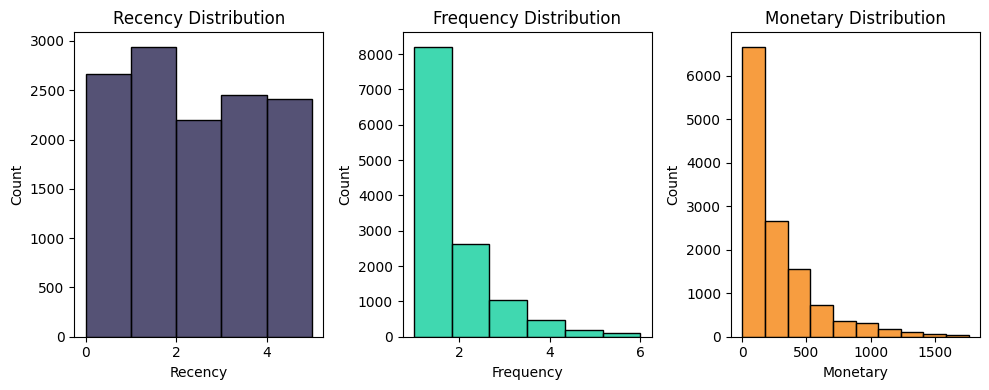

In [40]:
# visualize the distribution of "Recency", "Frequency", and "Monetary"
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(10,4))
sns.histplot(df_rfm_cleaned['Recency'], bins=5, ax=ax1, color='#1c1847')
ax1.set_title('Recency Distribution')
sns.histplot(df_rfm_cleaned['Frequency'], bins=6, ax=ax2, color='#00cc96')
ax2.set_title('Frequency Distribution')
sns.histplot(df_rfm_cleaned['Monetary'], bins=10, ax=ax3, color='#f57c00')
ax3.set_title('Monetary Distribution')
plt.tight_layout()
plt.show()

The RFM distribution reveals a highly skewed customer base. Frequency and Monetary are strongly right-skewed, indicating that the majority of customers purchase only once with relatively low spending (less than $500), while a small minority contributes disproportionately through higher repeat purchases and larger transaction values. Recency appears more evenly distributed, suggesting customer activity spans across different time windows, but this does not translate into strong repeat behavior.

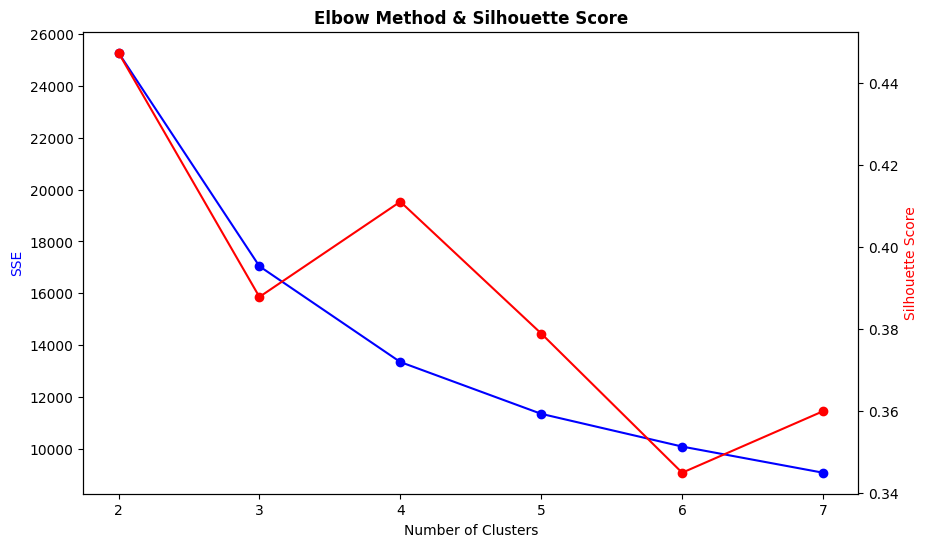

In [41]:
# Standardize & Setup
X = StandardScaler().fit_transform(df_rfm_cleaned)
sse, sil_scores, k_range = [], [], range(2, 8)

# Single loop for both metrics
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=241014, n_init=20).fit(X)
    sse.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(k_range, sse, 'bo-', label='SSE (Elbow)')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('SSE', color='b')

ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Elbow Method & Silhouette Score', fontweight='bold')
plt.show()

After evaluating both metrics, k=4 was selected as the optimal number of clusters for this segmentation.
- The SSE curve shows a steady decline, with a noticeable "elbow" or stabilization starting around k=4
- Although the Silhouette Score is highest at k=2, this configuration was rejected as it provides insufficient granularity for meaningful customer segmentation. Choosing k=4 allows for more actionable business insights while maintaining a strong Silhouette Score

In [42]:
# Fit final model
kmeans_final = KMeans(n_clusters=4, random_state=241014, n_init=20)
clusters = kmeans_final.fit_predict(X)

# Attach cluster ke dataframe asli
df_rfm_cleaned['cluster'] = clusters
df_rfm_cleaned

,Recency,Frequency,Monetary,cluster
0,4,1,119.03,1
1,5,1,55.16,1
2,4,3,57.15,0
3,3,2,345.72,1
4,4,2,57.85,1
...,...,...,...,...
13036,0,1,486.81,3
13037,0,1,444.51,3
13038,0,2,597.52,3
13039,0,3,881.65,2


In [43]:
df_rfm_cleaned.groupby('cluster').agg(
    Recency=('Recency','median'),
    Frequency=('Frequency','median'),
    Monetary=('Monetary','median'),
    Size=('cluster','size')
)

,Recency,Frequency,Monetary,Size
cluster,,,,
0,2.0,3.0,248.91,1280
1,4.0,1.0,84.89,4106
2,1.0,2.0,949.46,1097
3,1.0,1.0,166.02,6177


In [44]:
profile_list = {0: 'Loyal Customers', 1: 'New Customers', 2: 'Champions', 3: 'At Risk'}
df_rfm_cleaned['profile'] = df_rfm_cleaned['cluster'].map(profile_list)
dx = df_rfm_cleaned.groupby('profile').agg(
    Recency=('Recency','median'),
    Frequency=('Frequency','median'),
    Monetary=('Monetary','sum'),
    Average_Spend=('Monetary','mean'),
    Users = ('profile', 'size')
)
#dx['Revenue Contribution (%)'] = (dx['Monetary'] / dx['Monetary'].sum() * 100).round(2)
dx.sort_values('Monetary', ascending=False)

,Recency,Frequency,Monetary,Average_Spend,Users
profile,,,,,
At Risk,1.0,1.0,1307044.86,211.598650,6177
Champions,1.0,2.0,1113118.10,1014.692890,1097
New Customers,4.0,1.0,562117.27,136.901430,4106
Loyal Customers,2.0,3.0,379185.79,296.238898,1280


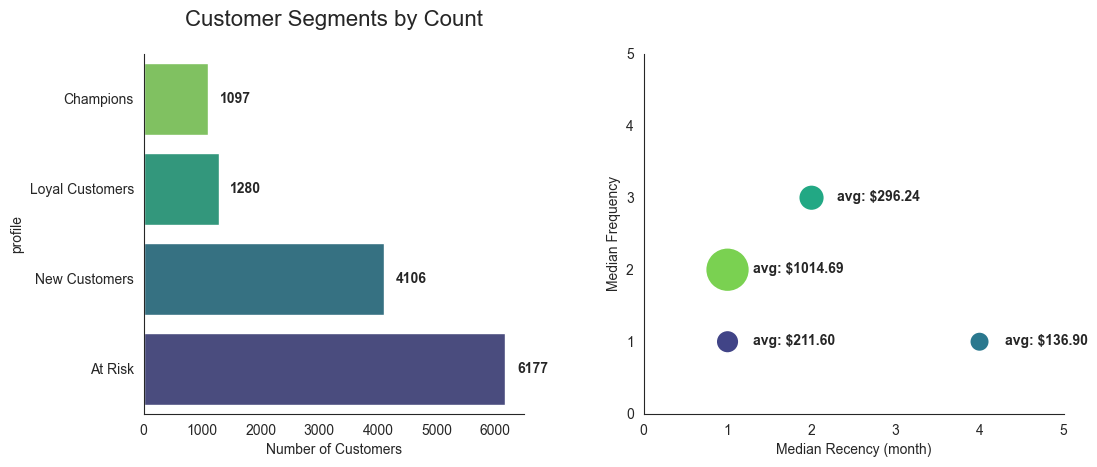

In [45]:
# visualize
plt.figure(figsize=(10,4))
seg_names=['Champions','Loyal Customers','New Customers','At Risk']

# plot the number of customers in each segment
sns.set_style("white")
plt.axes([0, 0, 0.38, 0.9])
seg=df_rfm_cleaned.groupby('profile').size().to_frame().rename(columns={0:'number of customers'}).reset_index()
sns.barplot(
    x='number of customers',
    y='profile',
    hue='profile',
    hue_order=seg_names[::-1],
    data=seg,
    order=seg_names,
    palette='viridis')

# add the number of customers in each segment as text on the bars
    
for i in seg_names:
    plt.text(seg['number of customers'][seg['profile']==i].iloc[0]+200, i, seg['number of customers'][seg['profile']==i].iloc[0], va='center', fontweight='bold')
plt.xlabel('Number of Customers')
plt.title('Customer Segments by Count', fontsize=16, pad=20)

# plot recency, frequency, and average spend/customer of the 4 segments
plt.axes([0.5,0,0.42,0.9])
sns.scatterplot(
    x='Recency',
    y='Frequency',
    hue='profile',
    hue_order=seg_names[::-1],
    palette='viridis',
    size='Average_Spend',
    sizes=(200,1000),
    legend=False,
    data=dx)

# add label average spend/customer as text on the points
for i in seg_names:
    plt.text(dx['Recency'][dx.index==i].iloc[0]+0.3, dx['Frequency'][dx.index==i].iloc[0]+0.01, 
             f"avg: ${dx['Average_Spend'][dx.index==i].iloc[0]:.2f}", 
             va='center', 
             fontweight='bold', 
             fontsize=10)
plt.ylim(0,5)
plt.xticks(list(range(6)))
plt.xlabel('Median Recency (month)')
plt.ylabel('Median Frequency')
sns.despine()

RFM Customer Profiling
- Champions (1,097 users)   
Customers with very recent activity, moderate purchase frequency, and the highest average spend (Over $1000 per User). This segment generates the strongest revenue contribution per user and represents the core high-value customer base. They demonstrate strong monetization quality despite smaller population size.

- Loyal Customers (1,280 users)     
Customers with relatively recent purchases and the highest purchase frequency, but moderate spending levels. They show consistent engagement and stable repeat behavior, making them a key segment for long-term retention and upselling strategies.

- New Customers (4,106 users)   
Recently acquired customers with low frequency and relatively low average spend. This segment represents acquisition success but weak conversion into repeat buyers. Their long-term value depends heavily on post-purchase engagement and retention efforts.

- At Risk (6,177 users)     
Largest segment with low frequency and low engagement signals despite prior transactions. Although their average spend per user is not negligible, their inactivity pattern indicates high churn risk. Immediate reactivation strategies are required to prevent further revenue leakage.

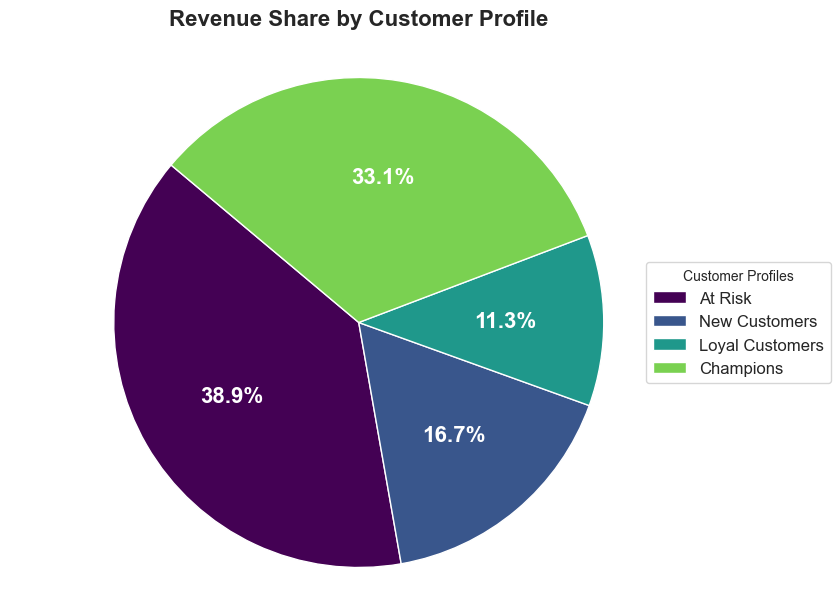

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Urutan yang kamu inginkan
seg_names = ['Champions', 'Loyal Customers', 'New Customers', 'At Risk']

# Mengurutkan dataframe dx berdasarkan list seg_names
dx_ordered = dx.reindex(seg_names[::-1])  # Reverse the list for plotting

labels = dx_ordered.index
values = dx_ordered['Monetary']

# Menggunakan viridis palette
colors = plt.cm.viridis(np.linspace(0, 0.8, len(labels)))
plt.figure(figsize=(9, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors,
        textprops={'fontsize': 16, 'fontweight': 'bold', 'color': "#FFFFFF"}
        )
# add legend
plt.legend(labels, title="Customer Profiles", loc="center left", bbox_to_anchor=(0.9, 0.5), fontsize=12)
plt.title('Revenue Share by Customer Profile', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal') 

plt.show()

Revenue distribution shows a structural imbalance across segments. The At Risk segment contributes the largest revenue share (38.9%), followed by Champions (33.1%), while New Customers (16.7%) and Loyal Customers (11.3%) contribute relatively smaller portions.

This indicates a critical risk exposure: a significant portion of revenue is generated by customers who show weak engagement signals and high churn probability. Meanwhile, Champions generate nearly one-third of total revenue despite representing a much smaller user base, confirming their high-value nature. The business currently depends heavily on segments with unstable retention.

## Conclusion

This end-to-end analysis reveals that while the platform successfully generates product views, conversion efficiency and long-term customer retention remain key growth constraints.

### Key Observation

- The largest drop in the purchase journey occurs between the view and cart stage, indicating weak purchase intent formation rather than checkout friction.
- Revenue is disproportionately concentrated among a relatively small segment of repeat buyers.
- Cohort analysis shows a sharp decline in retention after the first purchase month, suggesting limited customer lifecycle sustainability.
- RFM segmentation confirms that high-value customers contribute significantly to total revenue, yet a large portion of users remain low-frequency or one-time buyers.

### Business Risk

Without improving conversion and retention mechanisms, growth will remain dependent on continuous traffic acquisition, which may increase marketing costs and reduce margin efficiency.

### Strategic Priorities

- Improve product-level conversion drivers (pricing, product page optimization, promotion strategy).
- Implement structured retention programs targeting first-time buyers.
- Develop loyalty initiatives for high-value RFM segments.